In [1]:
!pip install moabb mne torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 6.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 10.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pytest
    Found existing installation: pytest 8.3.4
    Uninstalling pytest-8.3.4:
      Successfully uninstalled pytest-8.3.4━━━━━  0/11 [pytest]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [moabb]m10/11 [moabb]ds]]


In [3]:
from moabb.datasets import BNCI2014_001 # 이름 변경
from moabb.paradigms import MotorImagery

# 1. 데이터셋 로드 (이름 변경됨)
dataset = BNCI2014_001()
dataset.subject_list = [1] # 피험자 1번만

# 2. 패러다임 설정 (수정된 부분!)
# filters=[8, 32] 대신 fmin, fmax를 직접 써야 해.
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=32)

# 3. 데이터 가져오기
print("데이터 다운로드 및 로딩 중... (시간이 좀 걸릴 수 있어)")
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

# 4. 결과 확인
print("성공! 🎉")
print(f"데이터 형태 (Trials, Channels, Timepoints): {X.shape}")
# 예상 출력: (576, 22, 1001) - 576개 시행, 22개 채널, 약 4초 데이터
print(f"레이블 종류: {set(y)}")
# 예상 출력: {'feet', 'left_hand', 'right_hand', 'tongue'}

Choosing from all possible events
/opt/anaconda3/lib/python3.13/site-packages/moabb/datasets/download.py:60: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


데이터 다운로드 및 로딩 중... (시간이 좀 걸릴 수 있어)


/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


성공! 🎉
데이터 형태 (Trials, Channels, Timepoints): (576, 22, 1001)
레이블 종류: {np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue'), np.str_('feet')}


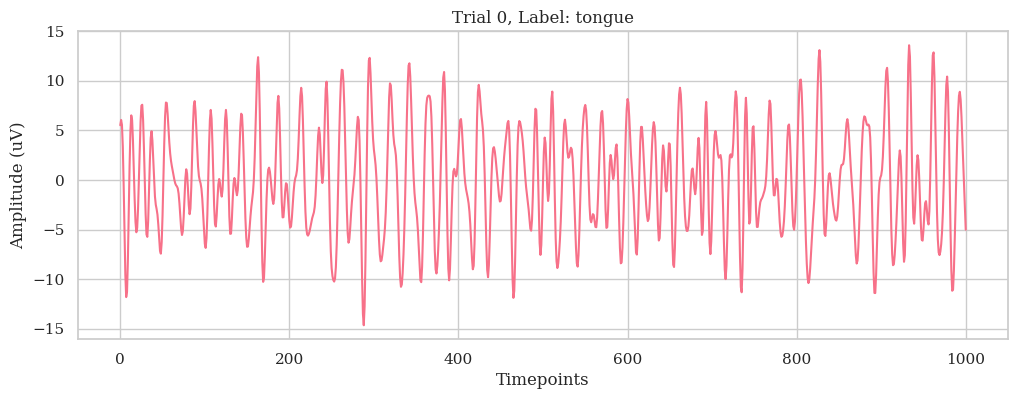

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 첫 번째 시행(Trial)의 첫 번째 채널(Channel) 데이터를 그려보자
trial_idx = 0
channel_idx = 0 # C3 or Cz 등 주요 채널일 가능성이 높음

plt.figure(figsize=(12, 4))
plt.plot(X[trial_idx, channel_idx, :])
plt.title(f"Trial {trial_idx}, Label: {y[trial_idx]}")
plt.xlabel("Timepoints")
plt.ylabel("Amplitude (uV)")
plt.grid(True)
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, ShuffleSplit
from sklearn.pipeline import Pipeline
from mne.decoding import CSP

# 1. 라벨 인코딩 (문자열 -> 숫자)
# 예: 'tongue' -> 0, 'feet' -> 1 ...
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"변환된 클래스: {le.classes_}")

# 2. CSP (Common Spatial Pattern) 정의
# 수업 Week 4에서 배우는 핵심 알고리즘이야.
# 4개의 클래스를 구분하기 위해 공간 필터(Spatial Filter)를 학습해.
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# 3. 분류기 (LDA) 정의
lda = LDA()

# 4. 파이프라인 구축 (CSP -> LDA 순서로 연결)
clf = Pipeline([('CSP', csp), ('LDA', lda)])

# 5. 교차 검증 (Cross-Validation)으로 성능 평가
# 데이터를 10번 섞어서(Shuffle) 학습/테스트를 반복해 평균 점수를 냄.
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
scores = cross_val_score(clf, X, y_encoded, cv=cv, n_jobs=1)

# 결과 출력
print(f"Cross-Validation Accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")
print(f"Chance Level (찍었을 때 확률): {1/len(le.classes_):.2f}")

변환된 클래스: ['feet' 'left_hand' 'right_hand' 'tongue']
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터 준비 (Numpy -> PyTorch Tensor)
# 딥러닝은 (Batch, 1, Channel, Time) 형태의 4차원 입력을 좋아해.
X_tensor = torch.FloatTensor(X).unsqueeze(1) # (576, 1, 22, 1001)
y_tensor = torch.LongTensor(y_encoded)       # 정답 라벨 (0~3)

# 학습용/테스트용 데이터 나누기 (80% 학습, 20% 테스트)
train_size = int(0.8 * len(X_tensor))
test_size = len(X_tensor) - train_size

train_dataset = TensorDataset(X_tensor[:train_size], y_tensor[:train_size])
test_dataset = TensorDataset(X_tensor[train_size:], y_tensor[train_size:])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. EEGNet 모델 정의 (Pytorch 구현)
class EEGNet(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001):
        super(EEGNet, self).__init__()
        
        # 첫 번째 블록: 시간적 특징(Temporal) + 공간적 특징(Spatial) 추출
        self.conv1 = nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False)
        self.batchnorm1 = nn.BatchNorm2d(8)
        self.depthwise = nn.Conv2d(8, 16, kernel_size=(Chans, 1), groups=8, bias=False)
        self.batchnorm2 = nn.BatchNorm2d(16)
        self.activation = nn.ELU()
        self.avgpool1 = nn.AvgPool2d(kernel_size=(1, 4))
        self.dropout1 = nn.Dropout(0.25)
        
        # 두 번째 블록: 특징 요약
        self.separable = nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8), groups=16, bias=False)
        self.batchnorm3 = nn.BatchNorm2d(16)
        self.avgpool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.dropout2 = nn.Dropout(0.25)
        
        # 마지막 분류기 (Fully Connected)
        # 입력 크기 계산이 좀 까다로운데, 대략 맞춰두고 실행하며 조정하는 게 팁이야.
        # (1001 -> pool4 -> pool8 로 줄어듦)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 31, nb_classes) # 16채널 * 31시점 (데이터 길이에 따라 다름)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.depthwise(x)
        x = self.batchnorm2(x)
        x = self.activation(x)
        x = self.avgpool1(x)
        x = self.dropout1(x)
        
        x = self.separable(x)
        x = self.batchnorm3(x)
        x = self.activation(x)
        x = self.avgpool2(x)
        x = self.dropout2(x)
        
        x = self.flatten(x)
        x = self.fc(x)
        return x

# 3. 모델 학습 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용 중인 장치: {device}")

model = EEGNet(nb_classes=4, Chans=22, Samples=X.shape[2]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 루프 (Training Loop)
print("딥러닝 학습 시작! 🚀")
for epoch in range(100): # 100번 반복
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {total_loss/len(train_loader):.4f}")

# 테스트 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n최종 Deep Learning 정확도: {100 * correct / total:.2f}%")

사용 중인 장치: cpu
딥러닝 학습 시작! 🚀
Epoch 10/100, Loss: 0.6291
Epoch 20/100, Loss: 0.4090
Epoch 30/100, Loss: 0.3054
Epoch 40/100, Loss: 0.3012
Epoch 50/100, Loss: 0.2219
Epoch 60/100, Loss: 0.2141
Epoch 70/100, Loss: 0.1485
Epoch 80/100, Loss: 0.1201
Epoch 90/100, Loss: 0.1282
Epoch 100/100, Loss: 0.1029

최종 Deep Learning 정확도: 74.14%


모델 예측 성공! (정답: 3, 예측: 3)


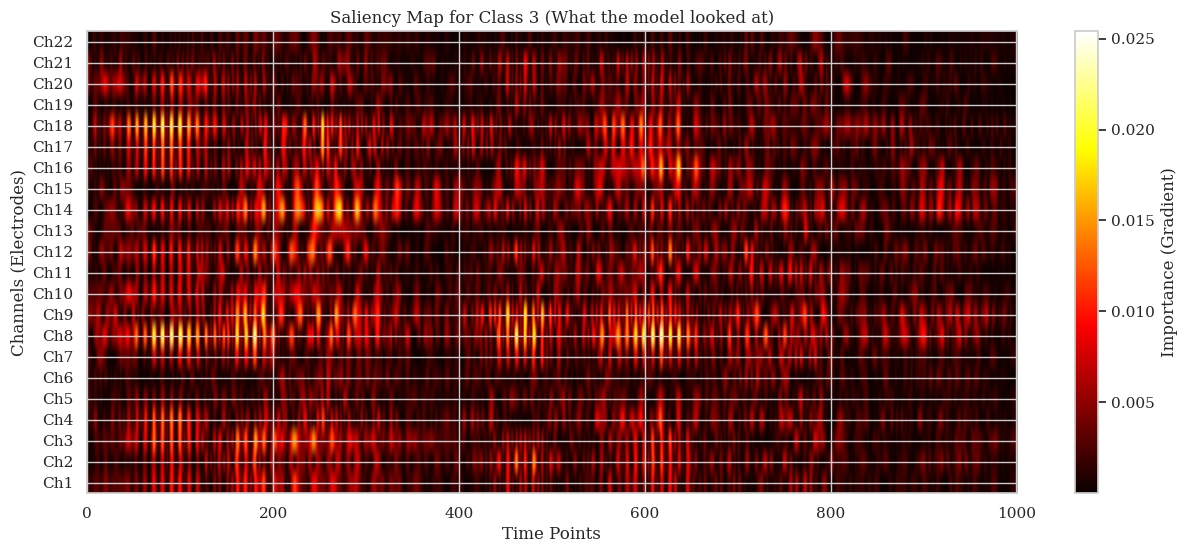

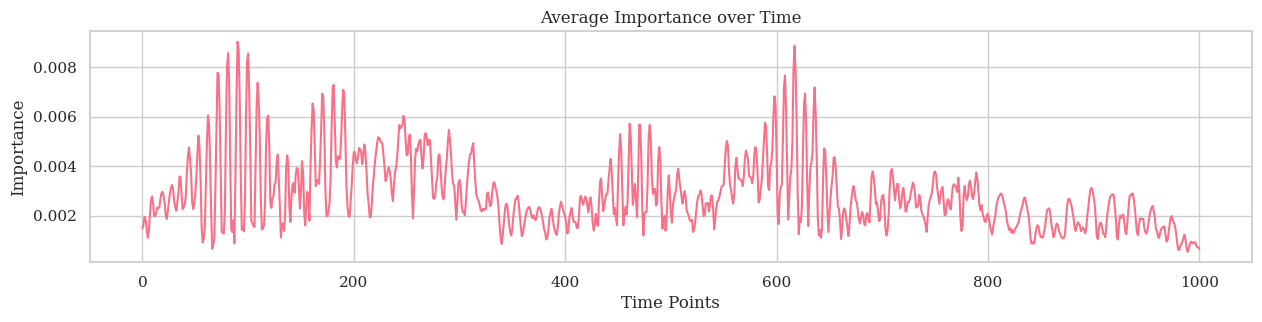

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델을 해석 모드로 설정
model.eval()

# 2. 분석할 샘플 하나 가져오기 (예: 테스트 셋의 첫 번째 데이터)
# 정답을 맞춘 케이스를 찾는 게 좋아.
sample_idx = 0
input_tensor, label = test_dataset[sample_idx]
input_tensor = input_tensor.unsqueeze(0).to(device) # (1, 1, 22, 1001)
input_tensor.requires_grad_() # 그래디언트 추적 켜기 (핵심!)

# 3. 모델 예측 및 역전파
output = model(input_tensor)
score, prediction = torch.max(output, 1)

if prediction.item() == label.item():
    print(f"모델 예측 성공! (정답: {label.item()}, 예측: {prediction.item()})")
else:
    print(f"모델 예측 실패... (정답: {label.item()}, 예측: {prediction.item()})")

# 정답 클래스에 대한 점수를 미분해서 입력 데이터까지 역전파
output[0, label.item()].backward()

# 4. Saliency Map 계산 (입력 데이터의 변화량이 출력에 미치는 영향)
# 절댓값을 취해서 '중요도'만 봅니다.
saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1) 
saliency = saliency.cpu().numpy().squeeze() # (22, 1001)

# 5. 시각화 (중요도 맵 그리기)
plt.figure(figsize=(15, 6))
plt.imshow(saliency, aspect='auto', cmap='hot', origin='lower')
plt.colorbar(label='Importance (Gradient)')
plt.xlabel('Time Points')
plt.ylabel('Channels (Electrodes)')
plt.title(f'Saliency Map for Class {label.item()} (What the model looked at)')
plt.yticks(range(22), [f'Ch{i+1}' for i in range(22)]) # 채널 이름이 있으면 더 좋음
plt.show()

# 6. (추가) 시간대별 평균 중요도
plt.figure(figsize=(15, 3))
plt.plot(np.mean(saliency, axis=0))
plt.title("Average Importance over Time")
plt.xlabel("Time Points")
plt.ylabel("Importance")
plt.grid(True)
plt.show()